# 01_encoding.ipynb

This notebook converts credit card transactions into visual encodings using Gramian Angular Fields, Recurrence Plots, and feature heatmaps.

In [9]:
import sys
import subprocess

required_packages = ['pyts']
for package in required_packages:
    try:
        __import__(package)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

print('Package check complete.')

Package check complete.


In [12]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append(str(Path('..').resolve()))
from src.encode import encode_gaf, encode_rp, encode_heatmap, save_image_dataset

sns.set(style='whitegrid')

In [13]:
data_path = Path('..') / 'data' / 'creditcard.csv'
if not data_path.exists():
    print('Dataset not found: data/creditcard.csv')
    print('1) Download it from Kaggle and place it in the data/ directory.')
    print('2) Or use the project helper if you have Kaggle credentials configured:')
    print('   python scripts/download_data.py')
    raise FileNotFoundError('Missing dataset: data/creditcard.csv')

df = pd.read_csv(data_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
print('Shape:', df.shape)
print('Fraud rate:', df['Class'].mean())

Shape: (284807, 31)
Fraud rate: 0.001727485630620034


In [15]:
sample = df.sample(n=12, random_state=42).reset_index(drop=True)
images_gaf = encode_gaf(sample, image_size=28)
images_rp = encode_rp(sample, image_size=28)
images_heatmap = encode_heatmap(sample, target_size=28)
print('GAF shape:', images_gaf.shape)
print('RP shape:', images_rp.shape)
print('Heatmap shape:', images_heatmap.shape)

GAF shape: (12, 28, 28)
RP shape: (12, 28, 28)
Heatmap shape: (12, 28, 28)


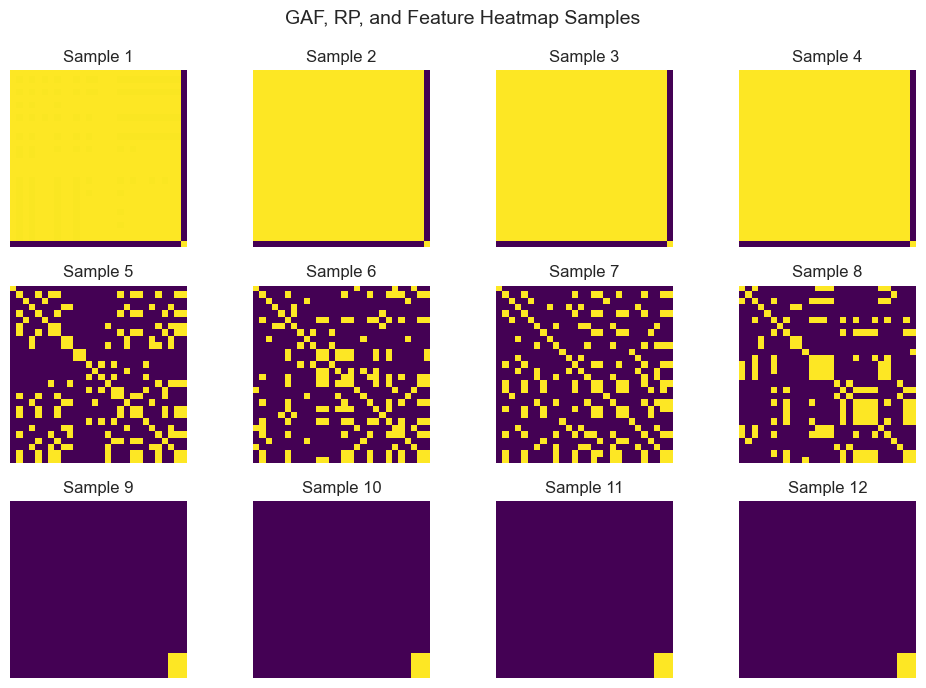

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i, ax in enumerate(axes.flatten()):
    img = images_gaf[i] if i < 4 else images_rp[i] if i < 8 else images_heatmap[i] 
    ax.imshow(img, cmap='viridis')
    ax.set_title(f'Sample {i + 1}')
    ax.axis('off')
plt.suptitle('GAF, RP, and Feature Heatmap Samples', fontsize=14)
plt.tight_layout()

In [18]:
images = encode_gaf(df, image_size=28)
labels = df['Class'].to_numpy(dtype=int)
output_path = Path('..') / 'data' / 'transactions_gaf_28.npz'
save_image_dataset(images, labels, str(output_path))
print('Saved GAF images to', output_path)

Saved GAF images to ..\data\transactions_gaf_28.npz


In [ ]:
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='viridis')
    plt.axis('off')
plt.suptitle('First 4 GAF Encoded Transactions', fontsize=14)
plt.show()